# Transformer
GPT·BERT·Gemini 등 현대 모든 LLM의 토대가 Transformer입니다. 이전 세대 모델(RNN/LSTM)은 문장을 한 단어씩 순서대로 처리했지만, 2017년 "Attention Is All You Need" 논문은 순차 처리를 버리고, 어텐션(attention) 으로 문장의 모든 단어가 동시에 의미관계를 파악할 수 있게 했습니다.
* 각 단어가 "나는 문맥의 어떤 단어에 주목해야 하나"를 직접 계산
* 모든 단어를 동시에 처리하므로 병렬화가 쉽고, 거리에 상관없이 관계를 봄

### 셀프 어텐션
각 단어가 같은 문장의 다른 단어를 둘러보며 "누구에게 얼마나 주목할지"를 스스로 정하는 것.
```
'그것' = [0, 0]  ← 아직 뜻이 비어 있음
  │
  ① 누구에게 주목? : 문장을 둘러보고 비율을 정함  →  사과 0.7,  빨개서 0.3   (합 = 1)
  │
  ② 그 비율대로 섞기 : 0.7 × [8, 2] + 0.3 × [2, 8] = [5.6, 1.4] + [0.6, 2.4]
  ▼
'그것' = [6.2, 3.8]  ← 사과 [8,2] 쪽으로 이동 = "그것 = 사과" 문맥을 품음
```

### Q·K·V와 어텐션 계산
어텐션 계산은 세 벡터를 기반으로 이루어집니다. 도서관에서 책 찾기에 빗대면 한 번에 이해됩니다.

도서관에서 내가 궁금한 게 있어 자료를 찾는다고 합시다.  

1) 나는 머릿속에 **찾고 싶은 키워드**를 떠올립니다 → Query(질의).
2) 책마다 등에 붙은 **색인표·제목**을 보고 내 키워드와 맞는지 비교합니다 → 그 색인표가 각 책의 Key(열쇠).
3) 키워드와 색인이 잘 맞는 책을 펼쳐 **실제 내용**을 가져옵니다 → 그 내용이 책의 Value(값).
단어 하나하나가 바로 이 "찾는 사람"이자 동시에 "책"입니다.


단어 하나하나가 바로 이 "찾는 사람"이자 동시에 "책"입니다.


| 이름 | 한 줄 뜻 |	도서관 비유 |	"그 사과는 빨개서 그것을 먹었다"에서 '그것'은|
|---|---|---|---|
|Query(질의)|내가 찾는 것|머릿속 검색 키워드|"나는 어떤 사물을 가리켜. 그 사물을 찾고 있어"|
|Key(열쇠)|	내가 내세우는 간판|각 책의 색인표·제목|(다른 단어들이) "나는 사과야 / 나는 색깔이야 ..."|
|Value(값)|내가 실제로 건넬 내용|책의 실제 내용|(사과가) 사과의 의미 정보|

### 멀티헤드 어텐션
어텐션은 "주목 비율"을 한 가지 기준(Q·K·V 한 세트)으로만 계산했습니다. 그런데 문장의 관계는 한 종류가 아닙니다.
* 예문: "키 큰 영희가 빨간 가방을 들고 학교에 갔다."
|관점|어떤 관계|	예|
|---|---|---|
|문법 관계|	주어 ↔ 서술어|'영희' ↔ '갔다'|
|수식 관계|	꾸미는 말 ↔ 꾸밈받는 말|	'빨간' ↔ '가방', '키 큰' ↔ '영희'|
|장소 관계|	행동 ↔ 장소	|'갔다' ↔ '학교'|

어텐션이 하나(head 1개) 뿐이면 이 중 한 관점만 보기 쉽습니다. 그래서 어텐션을 여러 개(head) 병렬로 두고, 각 head가 서로 다른 관계에 주목하게 합니다. 이것이 멀티헤드 어텐션(Multi-Head Attention) 입니다.

### Transformer 블록
```
                  ┌───────────────────── 블록(층) 하나 ──────────────────────┐
  단어 임베딩        │  ① 멀티헤드      ② 잔차연결                               │
  +  위치 인코딩  ──▶│   어텐션      ──▶  + LayerNorm  ──▶ ③ FFN ──▶ ② 잔차연결 │ ──▶ 다음 블록으로      
  (좌석 번호표)      │ (단어끼리 대화)   (안정화)        (혼자 곱씹기) + LayerNorm   │
                  └───────────────────────────────────────────────────────┘
                                  이 블록을 N층(예: 12층) 쌓는다
```

### 어텐션 가중치 확인

In [ ]:
import numpy as np

# softmax: 점수 벡터를 '합이 1인 확률'로 바꾼다(max를 빼는 건 큰 수 오버플로 방지용 관용구)
def softmax(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

rng = np.random.RandomState(0)            # 난수 고정(매번 같은 결과 = 재현성)
X = rng.randn(3, 4)                       # 입력: 토큰 3개 × 임베딩 차원 4 (예시)
# Wq/Wk/Wv: 입력을 Query/Key/Value로 변환하는 '학습 대상' 가중치(여기선 무작위로 대체)
Wq, Wk, Wv = rng.randn(4, 4), rng.randn(4, 4), rng.randn(4, 4)
Q, K, V = X @ Wq, X @ Wk, X @ Wv          # 각 토큰의 Query/Key/Value (@ = 행렬곱)

scores = Q @ K.T / np.sqrt(Q.shape[-1])   # ① Q·K 내적=궁합점수 → ② √차원으로 나눠 스케일 안정화
weights = softmax(scores)                 # ③ softmax → 주목 가중치(각 행의 합=1)
out = weights @ V                         # ④ Value를 가중합 = 문맥이 반영된 새 표현

print('어텐션 가중치(행 합=1):\n', weights.round(2))
print('가중치 행 합:', weights.sum(axis=1).round(2))   # [1. 1. 1.]
print('출력 shape:', out.shape)            # (3, 4) — 토큰마다 새 표현

어텐션 가중치(행 합=1):
 [[0.   1.   0.  ]
 [0.06 0.04 0.9 ]
 [0.07 0.91 0.01]]
가중치 행 합: [1. 1. 1.]
출력 shape: (3, 4)


### 위치 인코딩, 멀티헤드 어텐션 확인

In [ ]:
import numpy as np

# 1) 위치 인코딩 — 토큰 순서 정보를 더해준다(어텐션은 순서를 모르므로)
def positional_encoding(seq_len, d):
    pos = np.arange(seq_len)[:, None]
    i = np.arange(d)[None, :]
    angle = pos / np.power(10000, (2 * (i // 2)) / d)
    pe = np.zeros((seq_len, d))
    pe[:, 0::2] = np.sin(angle[:, 0::2])   # 짝수 차원 = sin
    pe[:, 1::2] = np.cos(angle[:, 1::2])   # 홀수 차원 = cos
    return pe

pe = positional_encoding(5, 8)
print('위치 인코딩 shape:', pe.shape)       # (5, 8): 위치마다 고유 패턴
print(pe.round(2))

# 2) 멀티헤드 — 임베딩을 head 개로 쪼개 각 head가 따로 어텐션(여기선 분할만 시연)
d_model, n_heads = 8, 2
x = np.random.RandomState(0).randn(5, d_model)
heads = x.reshape(5, n_heads, d_model // n_heads)   # (토큰, head, head_dim)
print('멀티헤드 분할:', x.shape, '->', heads.shape)  # (5,8) -> (5,2,4)

위치 인코딩 shape: (5, 8)
[[ 0.    1.    0.    1.    0.    1.    0.    1.  ]
 [ 0.84  0.54  0.1   1.    0.01  1.    0.    1.  ]
 [ 0.91 -0.42  0.2   0.98  0.02  1.    0.    1.  ]
 [ 0.14 -0.99  0.3   0.96  0.03  1.    0.    1.  ]
 [-0.76 -0.65  0.39  0.92  0.04  1.    0.    1.  ]]
멀티헤드 분할: (5, 8) -> (5, 2, 4)


#  어텐션 가중치 시각화
사전학습 한국어 BERT의 어텐션 가중치를 추출해 히트맵으로 그려, "어느 토큰이 어느 토큰에 주목하는지"를 눈으로 봅니다.

### 0. 준비

In [ ]:
#!pip install -q transformers torch matplotlib   # transformers: 사전학습 모델 허브, torch: 딥러닝 엔진
# AutoTokenizer/AutoModel: 모델 '이름'만 주면 알맞은 토크나이저·모델을 자동으로 받아주는 클래스
from transformers import AutoTokenizer, AutoModel
import torch, numpy as np, matplotlib.pyplot as plt

### 1. 어텐션 출력 모드로 모델 로드
`out.attentions` 는 (층 수)개의 텐서이고, 각 텐서는 `[배치, head, 토큰, 토큰]` 모양입니다.

In [ ]:
name = 'klue/bert-base'                    # 한국어로 사전학습된 BERT(Hugging Face 모델 이름)
tok = AutoTokenizer.from_pretrained(name)      # 그 모델 전용 토크나이저 내려받기
# output_attentions=True : 어텐션 가중치까지 함께 돌려달라고 요청(기본값은 안 줌)
model = AutoModel.from_pretrained(name, output_attentions=True)
model.eval()                               # 추론 모드(학습용 동작인 dropout 등을 끔)

sentence = '상품이 배송 중에 파손되어 환불을 원합니다'
inputs = tok(sentence, return_tensors='pt')   # 문장을 토큰 ID로 변환. 'pt'=파이토치 텐서로 반환
with torch.no_grad():                      # 기울기 계산 끔(추론만 하니 메모리·속도 이득)
    out = model(**inputs)                  # 모델에 입력 → 출력(어텐션 포함) 받기
tokens = tok.convert_ids_to_tokens(inputs['input_ids'][0])   # 토큰 ID를 사람이 읽는 문자열로
print('토큰:', tokens)
print('층 수:', len(out.attentions), '| 한 층 shape:', tuple(out.attentions[0].shape))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: klue/bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


토큰: ['[CLS]', '상품', '##이', '배송', '중', '##에', '파손', '##되', '##어', '환불', '##을', '원', '##합니다', '[SEP]']
층 수: 12 | 한 층 shape: (1, 12, 14, 14)


In [ ]:
! pip install koreanize_matplotlib
import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 51.1 MB/s eta 0:00:00


### 2. 마지막 층, head 0 히트맵
행(주목하는 토큰)에서 어떤 열(주목받는 토큰)이 진한지 봅니다. 의미가 연결된 토큰끼리 값이 큰 경향을 확인할 수 있습니다(완벽하진 않습니다 — head마다 보는 게 다릅니다).

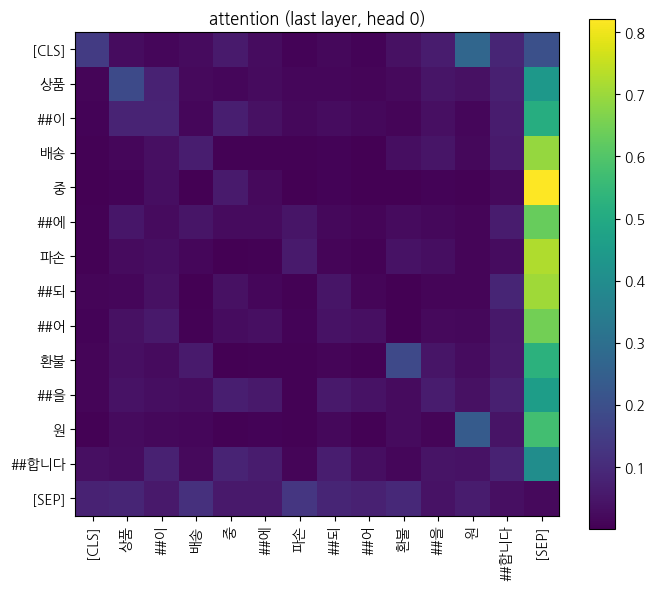

In [ ]:
att = out.attentions[-1][0]      # [-1]=마지막 층, [0]=배치 0 → 남은 모양 [head, 토큰, 토큰]
a = att[0].numpy()               # [0]=첫 번째 head 선택, 그림용으로 numpy 배열 변환
plt.figure(figsize=(7, 6))
plt.imshow(a, cmap='viridis')    # 2D 행렬을 색지도로 표시(값 클수록 밝게). cmap=색 팔레트
plt.xticks(range(len(tokens)), tokens, rotation=90)   # x축 눈금에 토큰 이름(90도 회전)
plt.yticks(range(len(tokens)), tokens)                # y축 눈금에 토큰 이름
plt.colorbar(); plt.title('attention (last layer, head 0)')   # 색-값 대응 막대 + 제목
plt.tight_layout(); plt.show()